In [1]:
import numpy as np

def relu(x):
    return np.maximum(0, x)

x = np.array([-3, -1, 0, 1, 3])
print(relu(x))

[0 0 0 1 3]


In [2]:
import numpy as np

# XOR dataset
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0],
              [1],
              [1],
              [0]])

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (4, 2)
Output shape: (4, 1)


In [9]:
np.random.seed(42)  # for reproducibility

# Layer 1 weights: (2 inputs → 3 hidden neurons)
W1 = np.random.normal(0, 0.1, size=(2, 3))
b1 = np.zeros((1, 3))

# Layer 2 weights: (3 hidden → 1 output)
W2 = np.random.normal(0, 0.1, size=(3, 1))
b2 = np.zeros((1, 1))
print("W1 shape:", W1.shape)
print("W2 shape:", W2.shape)

W1 shape: (2, 3)
W2 shape: (3, 1)


In [5]:
def relu(x):
    return np.maximum(0, x)

def forward(X, W1, b1, W2, b2):
    # Layer 1
    Z1 = np.dot(X, W1) + b1   # matrix multiply + bias
    A1 = relu(Z1)              # activation function
    
    # Layer 2
    Z2 = np.dot(A1, W2) + b2  # matrix multiply + bias
    A2 = sigmoid(Z2)           # output activation
    
    return Z1, A1, Z2, A2

In [10]:
import numpy as np

x = np.array([0, 1])
W1 = np.array([[0.1, 0.2, 0.3],
               [0.4, 0.5, 0.6]])

print(np.dot(x, W1))

[0.4 0.5 0.6]


In [11]:
Z1 = np.array([0.4, -0.2, 0.6])  # pretend one neuron got negative score
A1 = np.maximum(0, Z1)
print(A1)

[0.4 0.  0.6]


In [12]:
import numpy as np

# Input
X = np.array([0, 1])

# Weights (random for now)
np.random.seed(42)
W1 = np.random.normal(0, 0.1, size=(2, 3))
b1 = np.zeros(3)
W2 = np.random.normal(0, 0.1, size=(3, 1))
b2 = np.zeros(1)

# Layer 1
Z1 = np.dot(X, W1) + b1
A1 = np.maximum(0, Z1)

# Layer 2
Z2 = np.dot(A1, W2) + b2

print("Z1:", Z1)
print("A1 (after ReLU):", A1)
print("Z2 (final score):", Z2)

Z1: [ 0.15230299 -0.02341534 -0.0234137 ]
A1 (after ReLU): [0.15230299 0.         0.        ]
Z2 (final score): [0.02405188]


In [13]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

prediction = sigmoid(Z2)
print("Prediction:", prediction)
print("Correct answer: 1")
print("Error:", abs(1 - prediction))

Prediction: [0.50601268]
Correct answer: 1
Error: [0.49398732]


In [17]:
def mse_loss(y_pred, y_true):
    return np.mean((y_pred - y_true)**2)

loss = mse_loss(prediction, y[1])  # y[1] = correct answer for [0,1] input
print("Loss:", loss)

Loss: 0.24402347151652096


In [19]:
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y_true = np.array([[0],[1],[1],[0]])
y_true = np.array([[0], [1], [1], [0]])  # all XOR answers

# Forward pass on ALL examples
Z1 = np.dot(X, W1) + b1
A1 = np.maximum(0, Z1)
Z2 = np.dot(A1, W2) + b2
A2 = sigmoid(Z2)

# Loss gradient (how wrong is each prediction)
dA2 = 2 * (A2 - y_true) / len(X)
print("Loss gradient shape:", dA2.shape)
print("Loss gradient:", dA2)

Loss gradient shape: (4, 1)
Loss gradient: [[ 0.25      ]
 [-0.24699366]
 [-0.24939957]
 [ 0.25374404]]


In [22]:
import numpy as np

# Data
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

# Initialize weights
np.random.seed(42)
W1 = np.random.normal(0, 1, (2, 3))
b1 = np.zeros((1, 3))
W2 = np.random.normal(0, 1, (3, 1))
b2 = np.zeros((1, 1))

lr = 0.5
losses = []

# Training loop
for epoch in range(10000):
    # Forward pass
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)
    
    # Loss
    loss = np.mean((A2 - y)**2)
    losses.append(loss)
    
    # Backpropagation
    dA2 = 2 * (A2 - y) / len(X)
    dZ2 = dA2 * sigmoid(Z2) * (1 - sigmoid(Z2))
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0)
    
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * (Z1 > 0)
    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0)
    
    # Update weights
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

# Results
print("Final predictions:")
print(A2.round(3))
print("\nCorrect answers:")
print(y)
print("\nFinal loss:", loss)

Final predictions:
[[0.018]
 [0.992]
 [0.992]
 [0.007]]

Correct answers:
[[0]
 [1]
 [1]
 [0]]

Final loss: 0.00012019504515782279


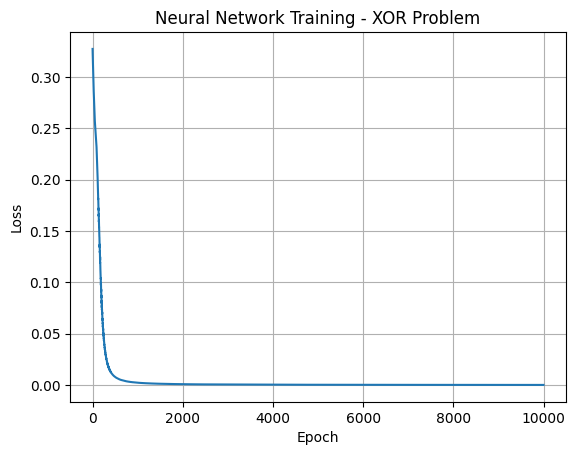

In [23]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title('Neural Network Training - XOR Problem')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()